# CelebAMask-HQ preprocessed-data test

Visual + numeric inspection of what `preprocess/preprocess_celebamaskhq.py` wrote to
`data_handlers/data/CelebAMaskHQ/preprocessed_data/{train,val,test}/{idx:05d}/{image.npy,label.npy}`.

This reads the `.npy` files straight off disk (the `CelebAMaskHQDataset` / `build_dataset()`
classes don't exist yet — that's the next step). It checks that the stored tensors match the
conventions every other dataset in this repo relies on:

* **image.npy** — `float32`, shape `(256, 256, 3)` HWC, values in `[0, 1]` (same range as the
  preprocessed CAMUS / CardiacUDA images; the model's reconstruction head is sigmoid, so the
  target has to live in `[0, 1]`).
* **label.npy** — `uint8`, shape `(8, 256, 256)` one-hot, channel 0 = background, and **every
  pixel sums to exactly 1 across the 8 channels** (the priority-order overlap resolution in
  `build_label()` exists specifically to keep this true — the raw attribute masks overlap).

8 classes: `0 background, 1 skin, 2 eyebrows, 3 eyes, 4 ears, 5 nose, 6 mouth, 7 hair`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# The notebook's working dir is this folder (data_handlers/data_loading/CelebAMaskHQ/).
# Try a couple of plausible locations so it also works if run from the repo root.
_CANDIDATES = [
    '../../data/CelebAMaskHQ/preprocessed_data',
    'data_handlers/data/CelebAMaskHQ/preprocessed_data',
]
PREPROCESSED_ROOT = next((p for p in _CANDIDATES if os.path.isdir(p)), _CANDIDATES[0])
print('preprocessed root :', os.path.abspath(PREPROCESSED_ROOT))
print('exists            :', os.path.isdir(PREPROCESSED_ROOT))

CLASS_NAMES = ['background', 'skin', 'eyebrows', 'eyes', 'ears', 'nose', 'mouth', 'hair']
NUM_CLASSES = len(CLASS_NAMES)

# Fixed palette for the 8 classes (background = black). Used by every mask visual below
# so colors stay consistent across cells.
CLASS_COLORS = np.array([
    [0.00, 0.00, 0.00],  # 0 background
    [0.90, 0.75, 0.65],  # 1 skin
    [0.85, 0.10, 0.10],  # 2 eyebrows
    [0.10, 0.55, 0.95],  # 3 eyes
    [0.95, 0.85, 0.15],  # 4 ears
    [0.15, 0.80, 0.35],  # 5 nose
    [0.90, 0.35, 0.75],  # 6 mouth
    [0.55, 0.30, 0.10],  # 7 hair
], dtype=np.float32)
CLASS_CMAP = ListedColormap(CLASS_COLORS)

preprocessed root : /mnt/mydrive/ilias/projects/unsupervised_learning/ICLR/ICLR/data_handlers/data/CelebAMaskHQ/preprocessed_data
exists            : True


## Loading helpers

In [2]:
def list_samples(split):
    """Sorted list of sample folder names (e.g. '00042') for a split."""
    split_dir = os.path.join(PREPROCESSED_ROOT, split)
    return sorted(os.listdir(split_dir))


def load_sample(split, name):
    """(image, label) for one sample, exactly as stored on disk — no casting/normalizing
    here so the checks below see the real dtypes/ranges.
    image: (256, 256, 3) float32 in [0, 1]        label: (8, 256, 256) uint8 one-hot
    """
    d = os.path.join(PREPROCESSED_ROOT, split, name)
    image = np.load(os.path.join(d, 'image.npy'))
    label = np.load(os.path.join(d, 'label.npy'))
    return image, label


def split_counts():
    return {s: len(list_samples(s)) for s in ('train', 'val', 'test')}


print('sample counts per split:', split_counts())

sample counts per split: {'train': 7251, 'val': 909, 'test': 790}


## Numeric sanity checks

`check_sample` returns a dict of everything that could be wrong; `check_split` runs it over a
whole split (or a random subset) and aggregates. Anything non-empty in `violations` is a bug
in preprocessing.

In [3]:
def check_sample(image, label):
    """Validate one (image, label) pair against this repo's stored-tensor conventions.
    Returns a dict; `violations` is a list of human-readable problem strings (empty = OK)."""
    v = []

    # --- image ---
    if image.dtype != np.float32:
        v.append(f'image dtype {image.dtype} != float32')
    if image.shape != (256, 256, 3):
        v.append(f'image shape {image.shape} != (256, 256, 3)')
    if image.min() < 0.0 or image.max() > 1.0:
        v.append(f'image range [{image.min():.4f}, {image.max():.4f}] outside [0, 1]')

    # --- label ---
    if label.dtype != np.uint8:
        v.append(f'label dtype {label.dtype} != uint8')
    if label.shape != (NUM_CLASSES, 256, 256):
        v.append(f'label shape {label.shape} != ({NUM_CLASSES}, 256, 256)')
    if not np.isin(np.unique(label), [0, 1]).all():
        v.append(f'label has non-binary values: {np.unique(label).tolist()}')
    # the invariant the whole codebase leans on: exactly one class per pixel
    pix_sum = label.sum(axis=0)
    if not (pix_sum == 1).all():
        counts = {int(k): int(c) for k, c in zip(*np.unique(pix_sum, return_counts=True))}
        v.append(f'not one-hot: pixel-sum histogram {counts}')

    present = np.where(label.reshape(NUM_CLASSES, -1).any(axis=1))[0].tolist()
    frac = label.reshape(NUM_CLASSES, -1).mean(axis=1)  # fraction of image area per class
    return {
        'violations': v,
        'classes_present': present,
        'area_fraction': frac,
        'image_min': float(image.min()),
        'image_max': float(image.max()),
    }


def check_split(split, n=None, seed=0):
    """Run check_sample over a split. n=None checks every sample; an int checks a random
    n-sample subset (fast smoke test while preprocessing is still running)."""
    names = list_samples(split)
    if n is not None and n < len(names):
        names = list(np.random.default_rng(seed).choice(names, size=n, replace=False))

    bad = []
    class_seen = np.zeros(NUM_CLASSES, dtype=int)
    area_sum = np.zeros(NUM_CLASSES)
    for name in names:
        image, label = load_sample(split, name)
        r = check_sample(image, label)
        if r['violations']:
            bad.append((name, r['violations']))
        class_seen[r['classes_present']] += 1
        area_sum += r['area_fraction']

    print(f"[{split}] checked {len(names)} samples — {len(bad)} with violations")
    for name, vs in bad[:10]:
        print(f'  {name}: {vs}')
    if len(bad) > 10:
        print(f'  ... and {len(bad) - 10} more')

    print(f"\n  {'class':<10} {'present in':>12}   {'mean area %':>12}")
    for c in range(NUM_CLASSES):
        print(f'  {CLASS_NAMES[c]:<10} {class_seen[c]:>7}/{len(names):<4}   '
              f'{100 * area_sum[c] / len(names):>11.2f}%')
    return bad

In [4]:
# Quick smoke test (random subset) — safe to run mid-preprocessing.
_ = check_split('train', n=300)

[train] checked 300 samples — 0 with violations

  class        present in    mean area %
  background     300/300          35.44%
  skin           300/300          25.97%
  eyebrows       297/300           0.84%
  eyes           298/300           0.46%
  ears           211/300           1.26%
  nose           300/300           2.02%
  mouth          300/300           1.39%
  hair           294/300          32.63%


In [5]:
# Full check of val + test (small splits), then the complete train split.
# Re-run once preprocessing has finished for a full-dataset guarantee.
_ = check_split('val')
print()
_ = check_split('test')
print()
_ = check_split('train')

[val] checked 910 samples — 0 with violations

  class        present in    mean area %
  background     910/910          34.21%
  skin           910/910          25.27%
  eyebrows       900/910           0.83%
  eyes           890/910           0.44%
  ears           606/910           1.25%
  nose           910/910           2.02%
  mouth          910/910           1.43%
  hair           900/910          34.56%

[test] checked 803 samples — 0 with violations

  class        present in    mean area %
  background     803/803          34.63%
  skin           803/803          25.34%
  eyebrows       794/803           0.83%
  eyes           792/803           0.46%
  ears           511/803           1.21%
  nose           803/803           2.01%
  mouth          802/803           1.43%
  hair           793/803          34.10%

[train] checked 7514 samples — 0 with violations

  class        present in    mean area %
  background    7514/7514         34.92%
  skin          7514/7514        

## Visualization functions

In [6]:
def class_map(label):
    """(8, H, W) one-hot -> (H, W) int class indices. argmax is exact here because the
    label is a validated one-hot (see check_sample)."""
    return label.argmax(axis=0)


def colorize(label):
    """(8, H, W) one-hot -> (H, W, 3) RGB image using the fixed CLASS_COLORS palette."""
    return CLASS_COLORS[class_map(label)]


def _legend_handles():
    from matplotlib.patches import Patch
    return [Patch(facecolor=CLASS_COLORS[c], edgecolor='k', label=f'{c} {CLASS_NAMES[c]}')
            for c in range(NUM_CLASSES)]


def show_sample(image, label, title=None, alpha=0.45):
    """Three panels: RGB image | colorized mask | image with mask overlaid."""
    fig, axs = plt.subplots(1, 3, figsize=(13, 4.6))
    axs[0].imshow(image); axs[0].set_title('image')
    axs[1].imshow(colorize(label)); axs[1].set_title('mask')
    axs[2].imshow(image)
    fg = class_map(label) != 0  # don't tint background pixels
    overlay = colorize(label)
    axs[2].imshow(np.dstack([overlay, alpha * fg]))
    axs[2].set_title(f'overlay (alpha={alpha})')
    for ax in axs:
        ax.axis('off')
    axs[1].legend(handles=_legend_handles(), loc='center left',
                  bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_channels(image, label, title=None):
    """Image + each of the 8 one-hot channels as its own binary panel — the direct way to
    eyeball that a class landed where it should and nowhere else."""
    fig, axs = plt.subplots(1, NUM_CLASSES + 1, figsize=(2.0 * (NUM_CLASSES + 1), 2.4))
    axs[0].imshow(image); axs[0].set_title('image', fontsize=9); axs[0].axis('off')
    for c in range(NUM_CLASSES):
        axs[c + 1].imshow(label[c], cmap='gray', vmin=0, vmax=1)
        axs[c + 1].set_title(f'{c} {CLASS_NAMES[c]}', fontsize=9)
        axs[c + 1].axis('off')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_grid(split, n=6, seed=0):
    """n random samples from a split, one row each: image | mask | overlay."""
    names = list_samples(split)
    picks = list(np.random.default_rng(seed).choice(names, size=min(n, len(names)), replace=False))
    fig, axs = plt.subplots(len(picks), 3, figsize=(9, 3.0 * len(picks)))
    axs = np.atleast_2d(axs)
    for row, name in enumerate(picks):
        image, label = load_sample(split, name)
        fg = class_map(label) != 0
        axs[row, 0].imshow(image)
        axs[row, 1].imshow(colorize(label))
        axs[row, 2].imshow(image)
        axs[row, 2].imshow(np.dstack([colorize(label), 0.45 * fg]))
        axs[row, 0].set_ylabel(f'{split}/{name}', fontsize=9)
        for col in range(3):
            axs[row, col].set_xticks([]); axs[row, col].set_yticks([])
    for col, t in enumerate(['image', 'mask', 'overlay']):
        axs[0, col].set_title(t)
    plt.tight_layout()
    plt.show()

## Look at the data

train/00015  image float32 (256, 256, 3)  [0.035, 0.992]  |  label uint8 (8, 256, 256)


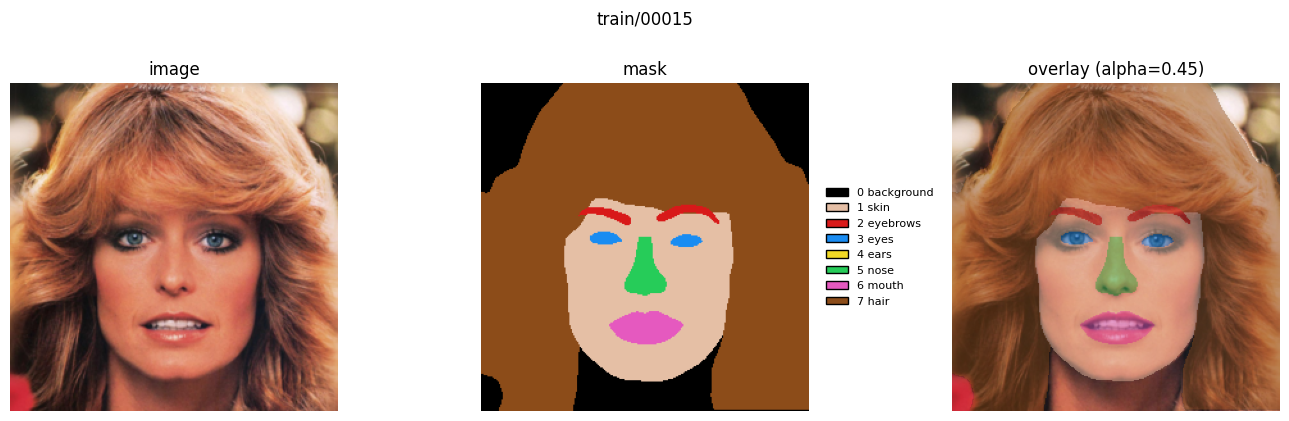

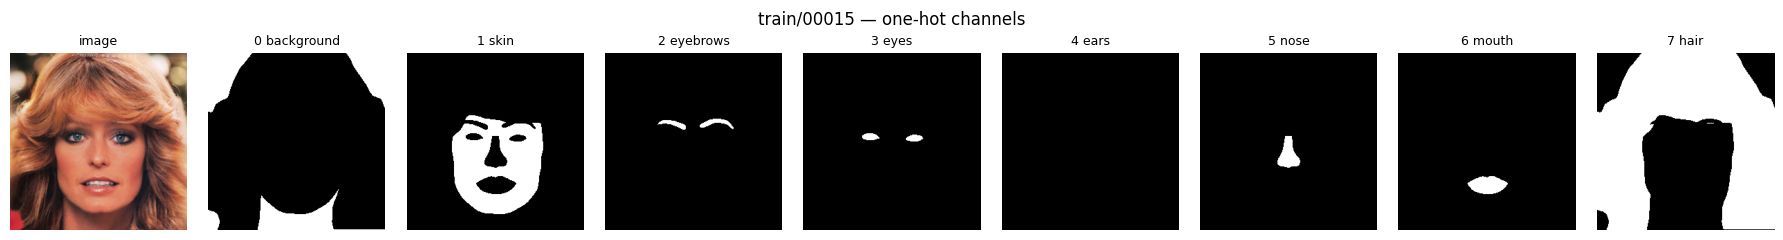

In [16]:
# One detailed sample: 3-panel view + per-channel breakdown.
name = list_samples('train')[10]
image, label = load_sample('train', name)
print('train/%s  image %s %s  [%.3f, %.3f]  |  label %s %s' % (
    name, image.dtype, image.shape, image.min(), image.max(), label.dtype, label.shape))
show_sample(image, label, title=f'train/{name}')
show_channels(image, label, title=f'train/{name} — one-hot channels')

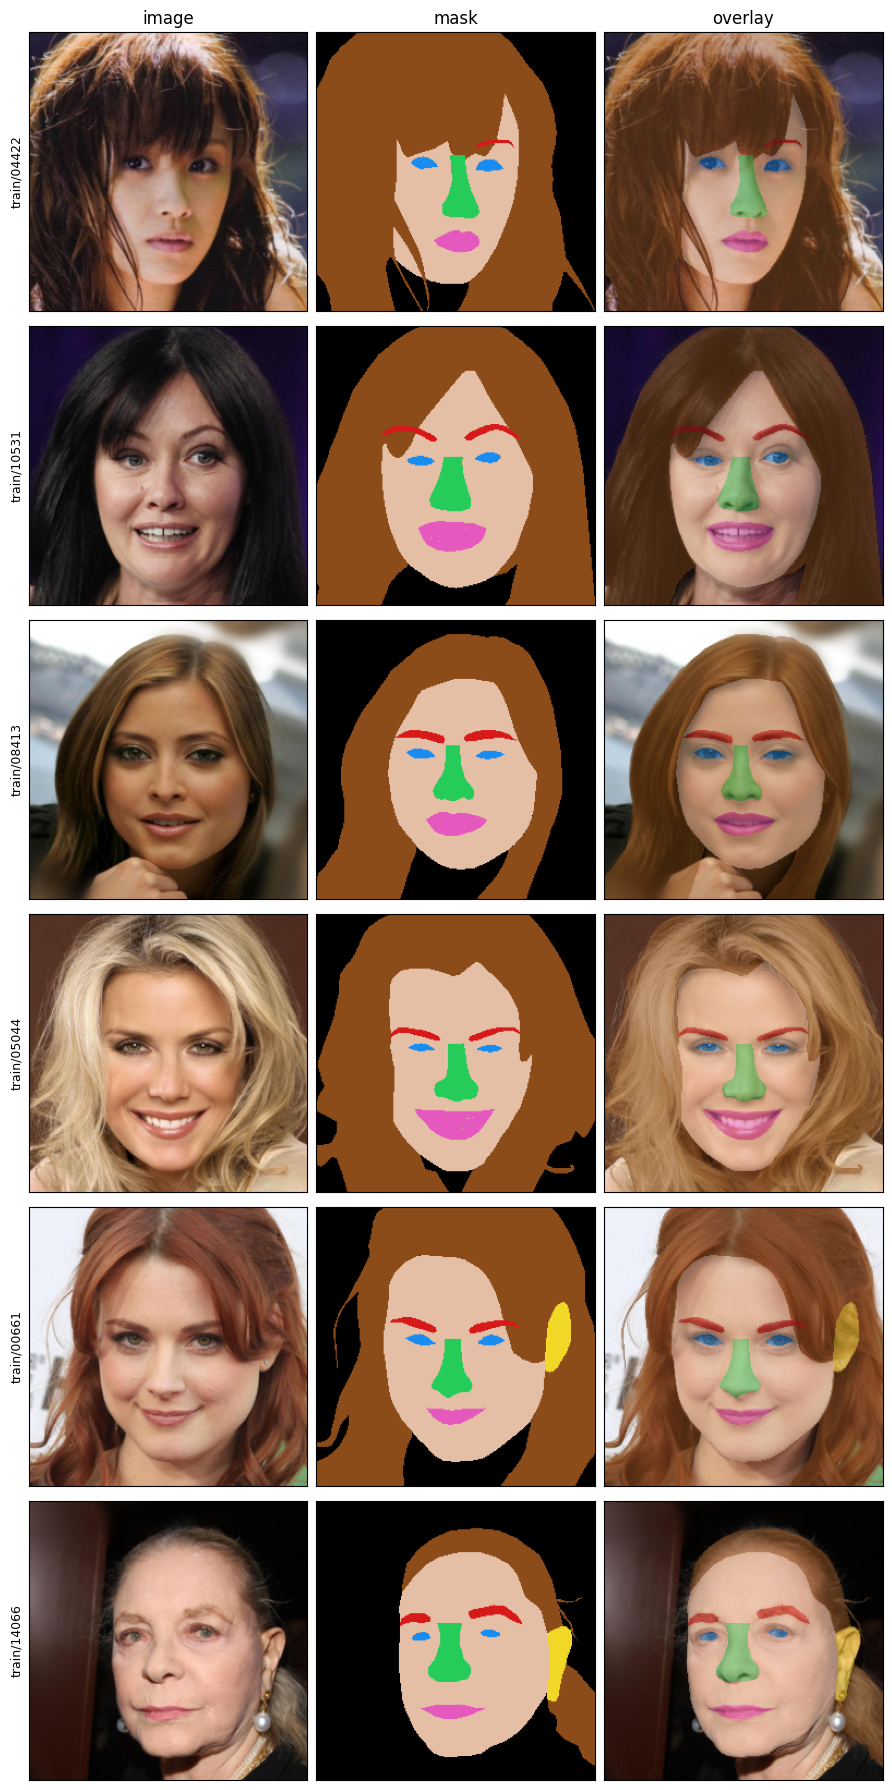

In [19]:
show_grid('train', n=6, seed=0)

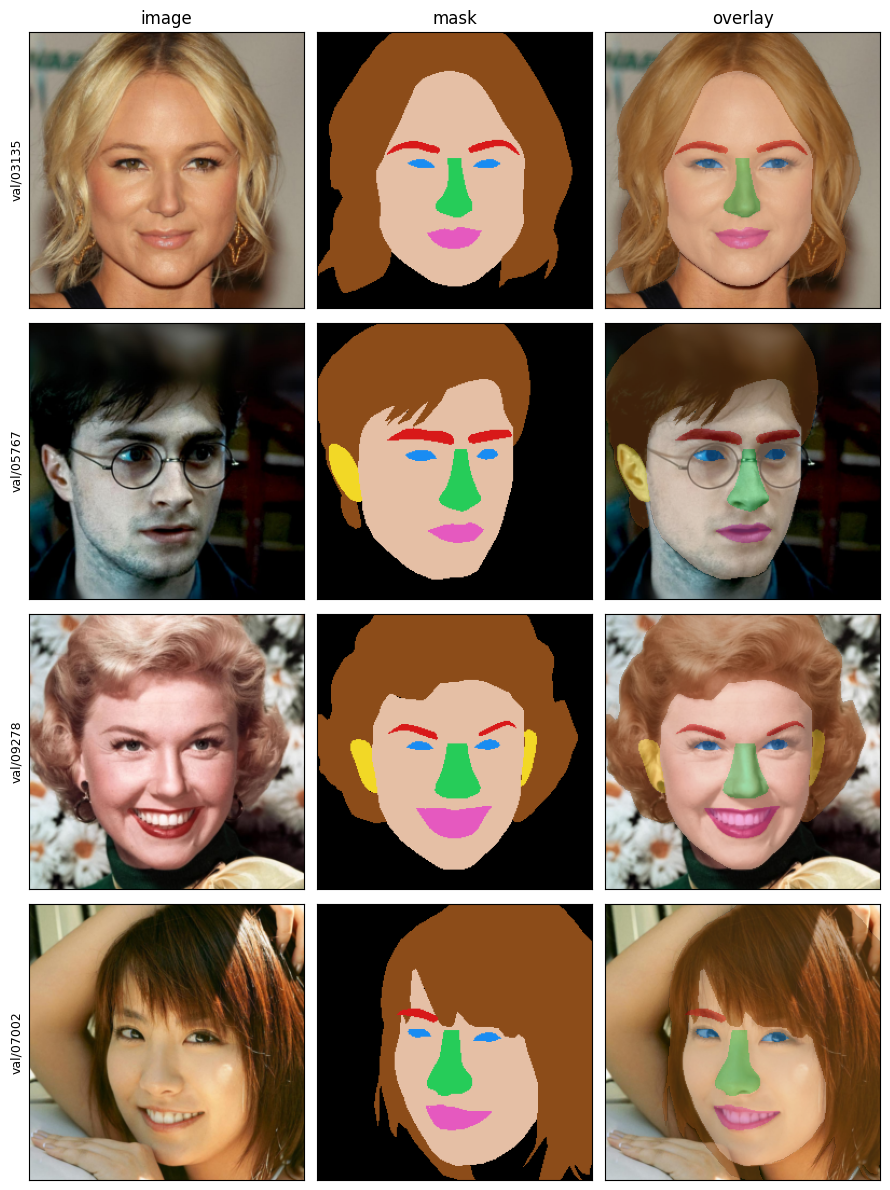

In [9]:
show_grid('val', n=4, seed=0)

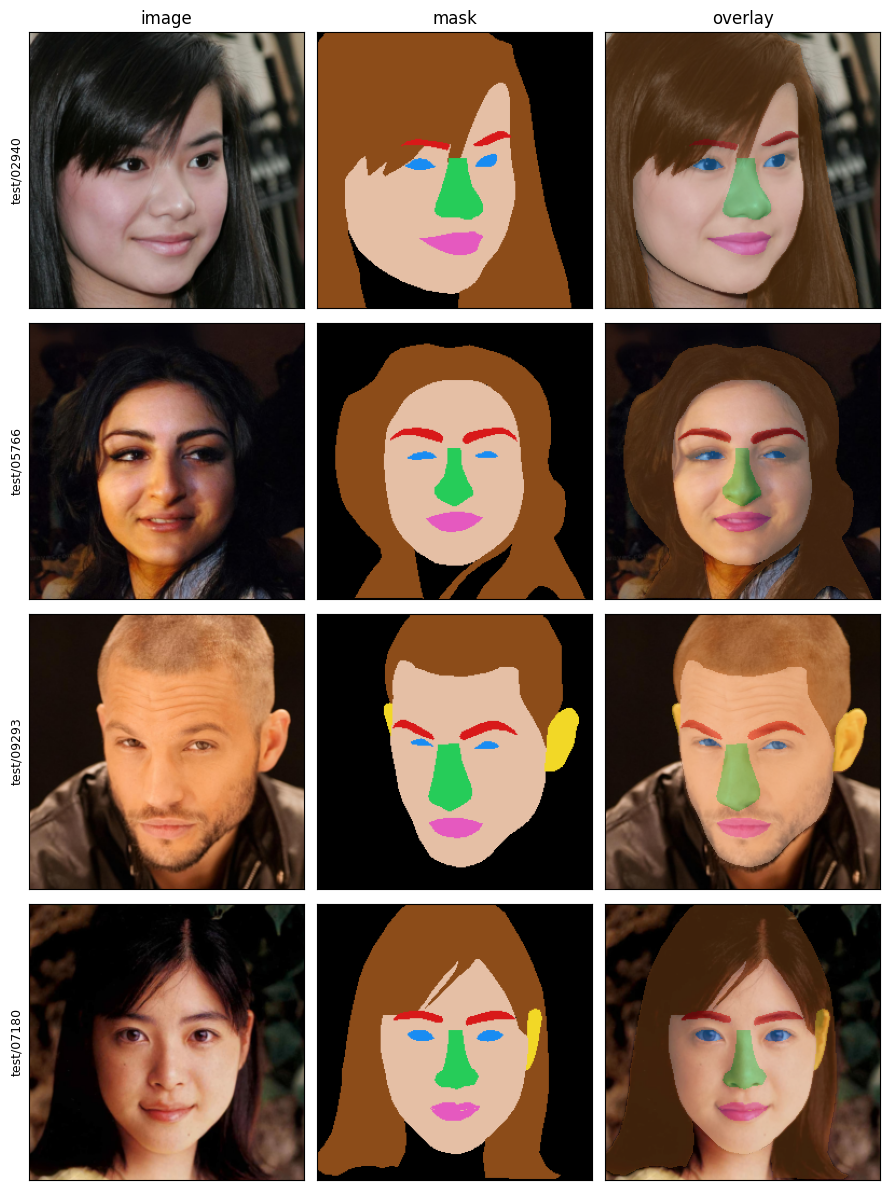

In [10]:
show_grid('test', n=4, seed=0)

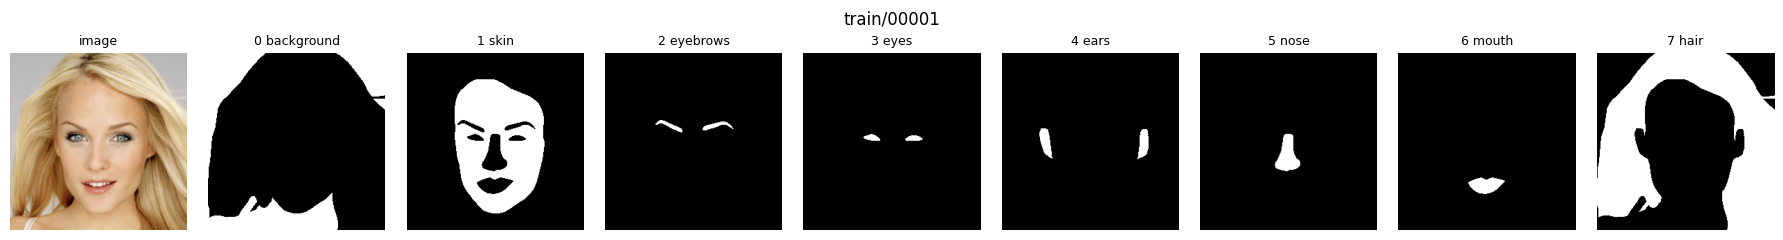

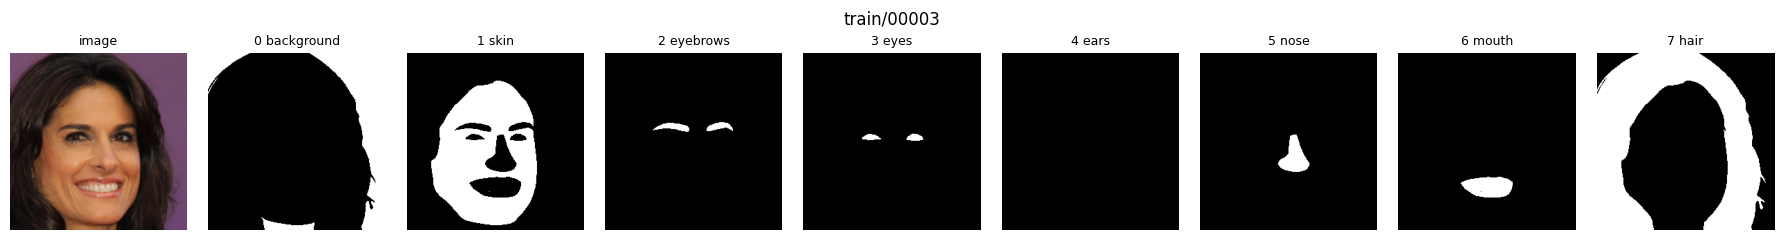

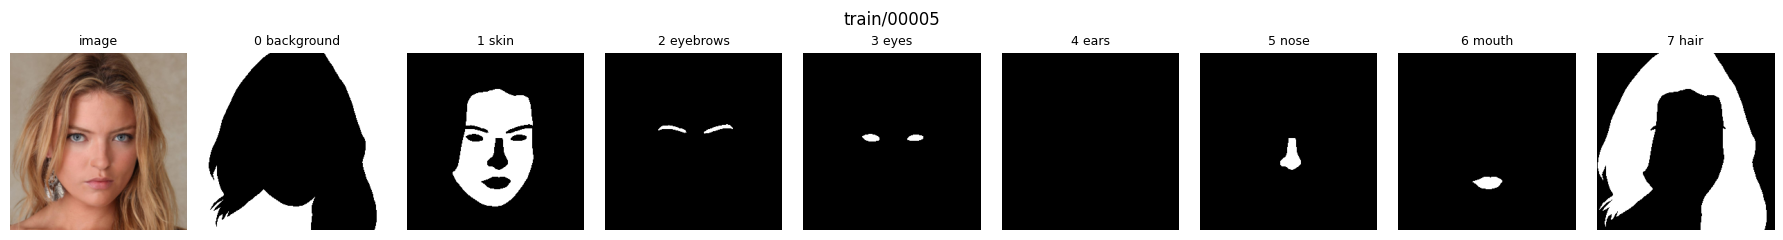

In [11]:
# A few more per-channel breakdowns — handy for spotting eyebrow/eye/ear leakage,
# which is where the priority-order overlap fix matters most.
for nm in list_samples('train')[1:4]:
    img, lab = load_sample('train', nm)
    show_channels(img, lab, title=f'train/{nm}')